In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


# **Model: Logistic Regression**

In [2]:
X_train = pd.read_csv("../data/X_train.csv", index_col=0)
X_test = pd.read_csv("../data/X_test.csv", index_col=0)
y_train = pd.read_csv("../data/y_train.csv", index_col=0).squeeze()
y_test = pd.read_csv("../data/y_test.csv", index_col=0).squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (78415, 10)
X_test shape: (19604, 10)


# **Baseline**

In [3]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.54


# **Build Model**

In [4]:
categorical_cols = X_train.select_dtypes("object").columns.tolist()
numeric_cols = X_train.select_dtypes("number").columns.tolist()
categorical_cols, numeric_cols

/tmp/ipykernel_544/1257538748.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes("object").columns.tolist()


(['land_surface_condition',
  'foundation_type',
  'roof_type',
  'ground_floor_type',
  'other_floor_type',
  'position',
  'plan_configuration'],
 ['age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq'])

In [5]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
], remainder="passthrough")

model = Pipeline([
    ("preprocessor", preprocessor),
    ("logisticregression", LogisticRegression(max_iter=1000))
])
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

# **Evaluate**

In [6]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = accuracy_score(y_test, model.predict(X_test))

print("Training Accuracy:", round(acc_train, 3))
print("Test Accuracy:", round(acc_test, 3))

Training Accuracy: 0.651
Test Accuracy: 0.65


# **Communicate Results**

In [7]:
cat_features = model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_features = list(cat_features) + numeric_cols
coefs = model.named_steps["logisticregression"].coef_[0]

# odds ratios -- exponentiating the coefficients makes them easier to interpret
# (a value of 2.0 means that feature roughly doubles the odds of severe damage)
odds_ratios = pd.Series(np.exp(coefs), index=all_features).sort_values()
odds_ratios.head()

foundation_type_RC                 0.397388
roof_type_RCC/RB/RBC               0.430240
ground_floor_type_RC               0.462924
foundation_type_Bamboo/Timber      0.565950
other_floor_type_Not applicable    0.636266
dtype: float64

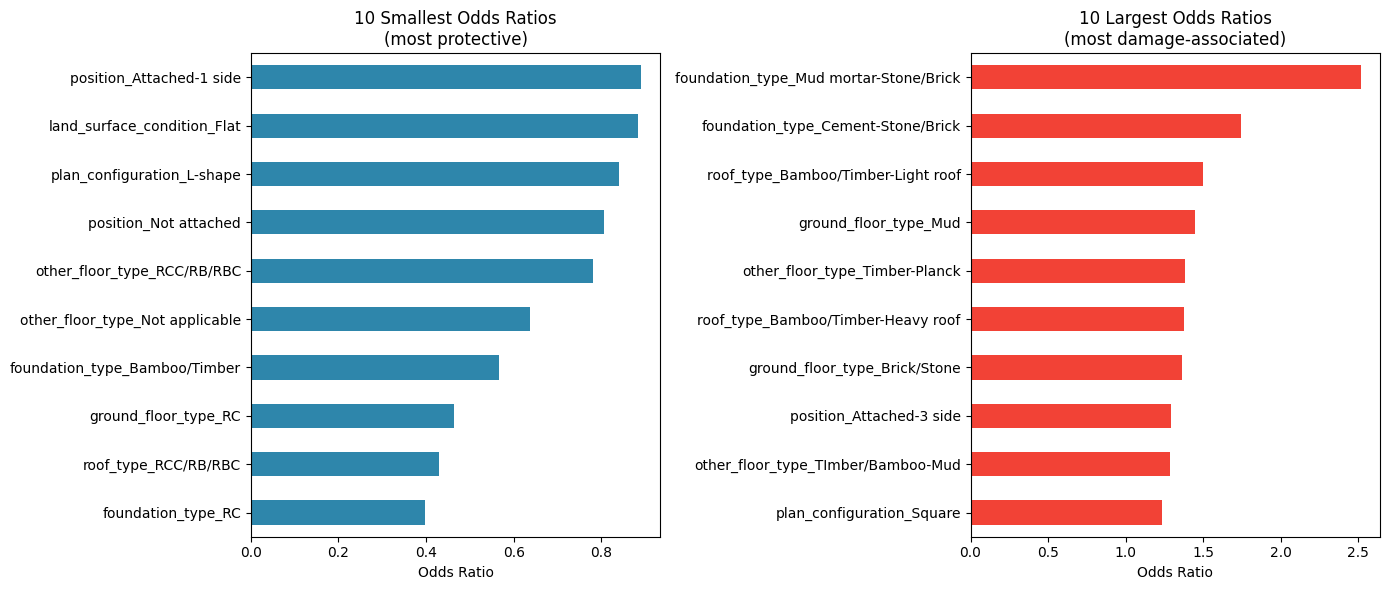

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

odds_ratios.head(10).plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_xlabel("Odds Ratio")
axes[0].set_title("10 Smallest Odds Ratios\n(most protective)")

odds_ratios.tail(10).plot(kind="barh", ax=axes[1], color="#F24236")
axes[1].set_xlabel("Odds Ratio")
axes[1].set_title("10 Largest Odds Ratios\n(most damage-associated)")

plt.tight_layout()
plt.savefig("../images/logreg_odds_ratios.png", dpi=150)
plt.show()


In [9]:
with open("../data/2_model_logreg_results.txt", "w") as f:
    f.write(str(acc_test))
print("saved:", acc_test)

saved: 0.6499183840032646
